<a href="https://colab.research.google.com/github/Rabia-Batool9/supervised-machine-learning-model/blob/main/rabia_batool_Logistic_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment: Logistic Regression on Loan Risk Prediction Dataset**

**1️  Introduction**

Loan risk prediction is an important task in the banking and finance sector. Financial institutions use machine learning algorithms to predict whether a loan applicant is risky or safe before approving loans.

In this assignment, we use the Logistic Regression Algorithm to predict loan risk using the dataset:

Logistic Regression is a supervised machine learning classification algorithm used for predicting categorical outcomes such as:


Approved / Rejected
Fraud / Not Fraud
Risky / Safe

**Import Libraries**

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/loan_risk_prediction_dataset (1).csv")
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,Male,PhD,Houston,Salaried,1


**Dataset Overview**

In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print(df.columns)

# Data types
df.info()

# Check missing values
df.isnull().sum()

Dataset Shape: (5000, 10)
Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


**Statistical Summary**

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# df.drop(columns=["fraud_type"], inplace=True)

In [ ]:
# Missing indicator
# df["is_first_transaction"] = (
#     df["time_since_last_transaction"]
#     .isnull()
#     .astype(int)
# )

# # Fill missing values
# df["time_since_last_transaction"] = (
#     df["time_since_last_transaction"]
#     .fillna(-1)
# )

In [ ]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Age': 0, 'Income': 31, 'LoanAmount': 32, 'CreditScore': 0, 'YearsExperience': 0, 'LoanApproved': 1151}


In [ ]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

            Column  Outlier_Count
5     LoanApproved           1151
2       LoanAmount             32
1           Income             31
0              Age              0
3      CreditScore              0
4  YearsExperience              0


In [ ]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

            Column  Outlier_Count  Percentage
5     LoanApproved           1151       23.02
2       LoanAmount             32        0.64
1           Income             31        0.62
0              Age              0        0.00
3      CreditScore              0        0.00
4  YearsExperience              0        0.00


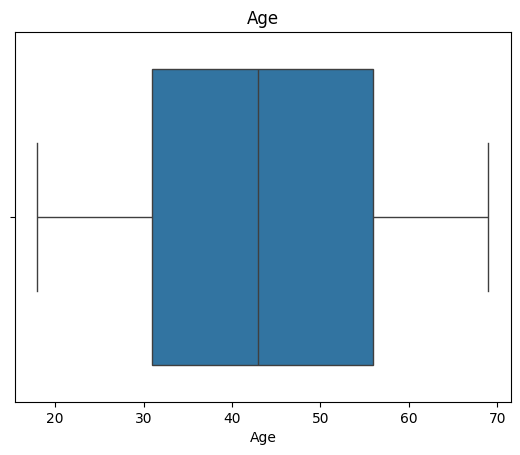

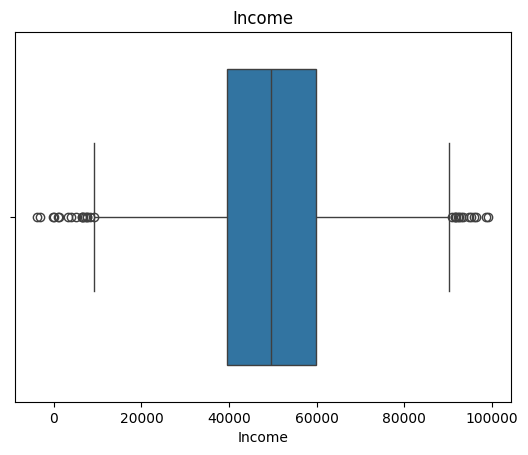

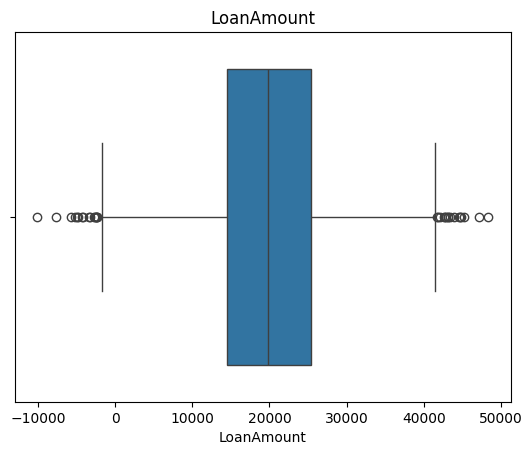

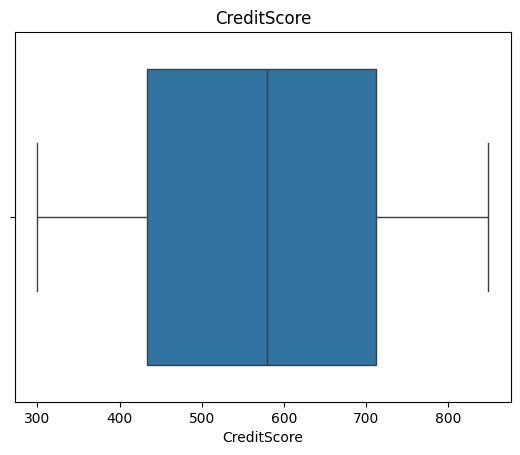

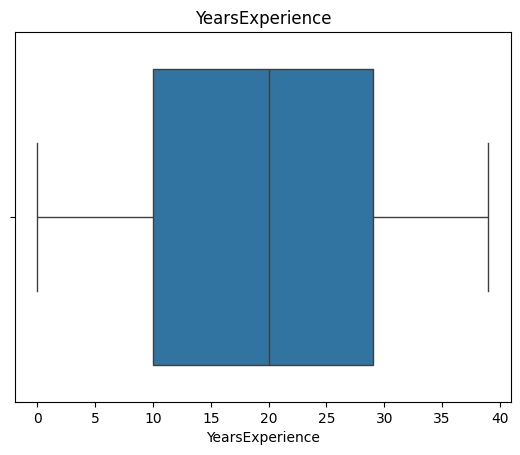

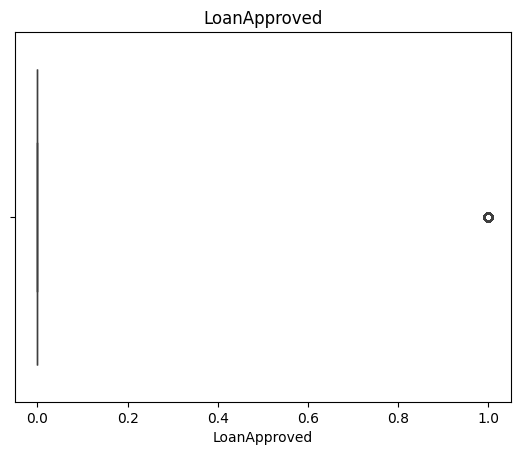

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

This step helps understand:

*  Mean
*  Median
*   Standard deviation
*  Minimum and maximum values

**Data Preprocessing**
Convert Categorical Columns into Numerical Values

In [ ]:
# Create Label Encoder
le = LabelEncoder()

# Convert categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Display dataset
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,0,1,1,2,0
1,69,57462.0,23262.0,586.0,6,1,1,3,1,0
2,46,44219.0,26530.0,781.0,26,1,3,1,1,1
3,32,56307.0,11531.0,549.0,11,1,4,2,2,0
4,60,37034.0,27871.0,500.0,19,0,1,0,2,0


**Define Features and Target Variable**

In [ ]:
# Features
X = df.drop('LoanApproved', axis=1)

# Target variable
y = df['LoanApproved']


If your target column name is different, replace 'Loan_Status' with your actual target column name.

**Train-Test Split**

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4000, 9)
Testing Data Shape: (1000, 9)


**Apply Logistic Regression**

In [ ]:
# Create model
model = LogisticRegression()

# Impute missing values in X_train and X_test
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both training and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train model with scaled and imputed data
model.fit(X_train_scaled, y_train)

# Predictions with scaled and imputed data
y_pred = model.predict(X_test_scaled)

**Model Evaluation**
Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.862


**Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[731  44]
 [ 94 131]]


**Visualization of Confusion Matrix**

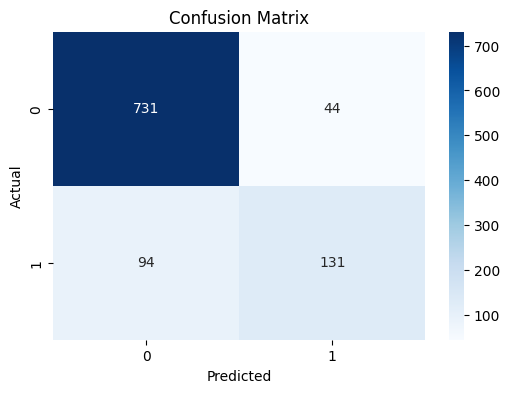

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Classification Report**

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       775
           1       0.75      0.58      0.66       225

    accuracy                           0.86      1000
   macro avg       0.82      0.76      0.78      1000
weighted avg       0.86      0.86      0.86      1000



The classification report shows:

Precision
Recall
F1-Score
Accuracy

**Feature Importance**

In [ ]:
# Feature coefficients
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', ascending=False)

print(importance)

           Feature  Coefficient
3      CreditScore     1.945528
1           Income     0.909962
6        Education     0.065117
2       LoanAmount     0.054682
7             City     0.019373
5           Gender     0.016001
4  YearsExperience    -0.010571
0              Age    -0.063356
8   EmploymentType    -1.183493


**Data Visualization**
Distribution of Target Variable

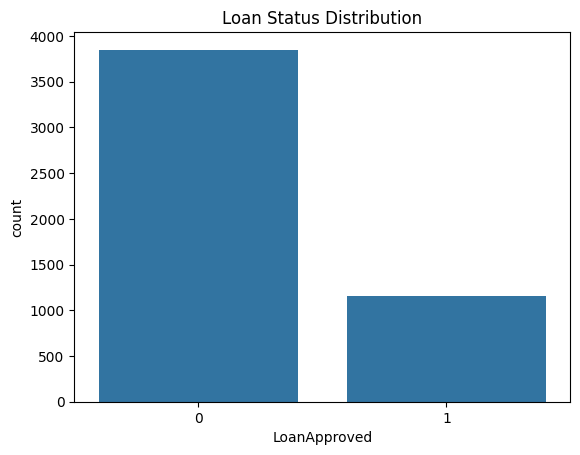

In [ ]:
sns.countplot(x=y)
plt.title("Loan Status Distribution")
plt.show()

**Correlation Heatmap**

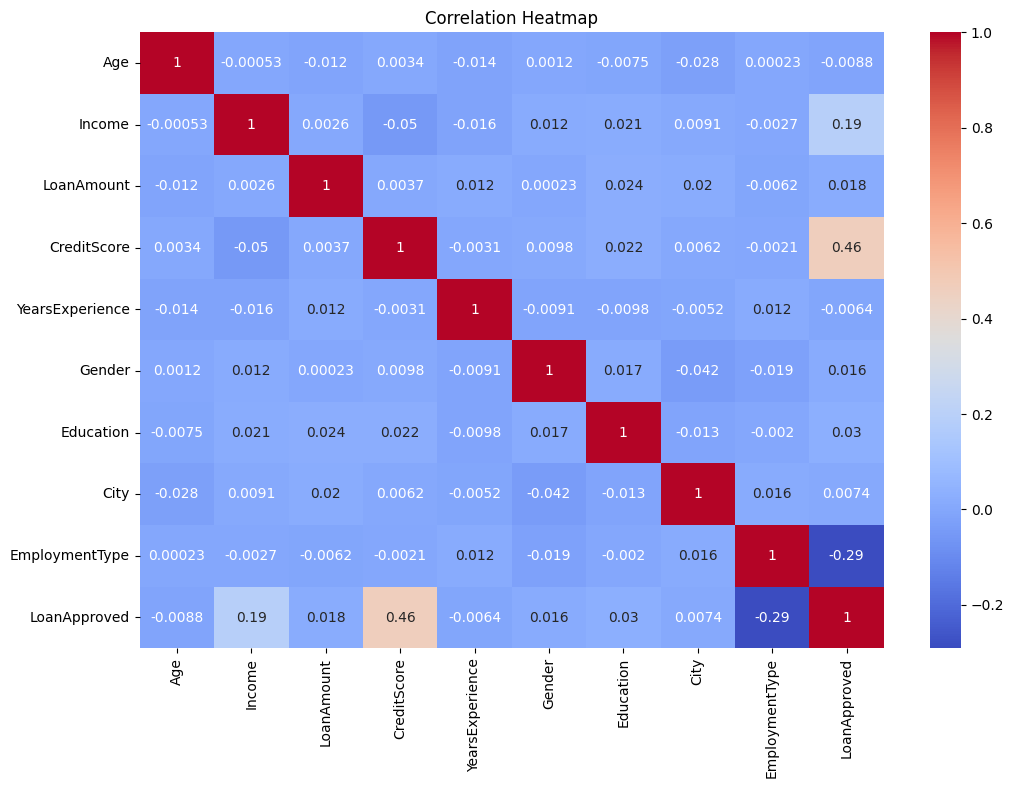

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# **Insights**

**Observation 1**

Logistic Regression successfully classified loan applicants into risky and non-risky categories.

** Insight**

The model learned patterns from customer information such as income, loan amount, employment, and credit history.

** Recommendation**

Banks can use this model for initial loan screening to reduce manual work.

#  Observation 2

Some features showed stronger influence on loan approval prediction.

 **Insight**

Features with higher coefficients have greater impact on predicting loan risk.


** Recommendation **

Financial institutions should focus more on these important features during verification.

# **Observation 3**

The confusion matrix shows how many predictions were correct and incorrect.

** Insight**

False predictions still exist, meaning the model is not perfect.

**Recommendation**

Use additional algorithms such as Random Forest or XGBoost for better performance.

# **Advantages of Logistic Regression**



* Simple and easy to implement
* Fast training process
* Interpretable results
* Works well on structured datasets

** Limitations**

* Works best with linear relationships
* Sensitive to outliers
* Performance may decrease on complex datasets

# **Conclusion**

In this project, Logistic Regression was applied on the Loan Risk Prediction dataset to classify loan applicants.

The complete machine learning workflow included:

* Data loading
* Data preprocessing
* Encoding categorical variables
* Train-test splitting
* Model training
* Prediction
* Model evaluation

# **Final Complete Code**

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age            

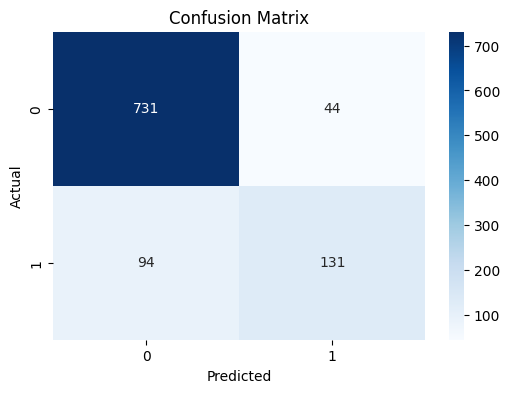

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       775
           1       0.75      0.58      0.66       225

    accuracy                           0.86      1000
   macro avg       0.82      0.76      0.78      1000
weighted avg       0.86      0.86      0.86      1000



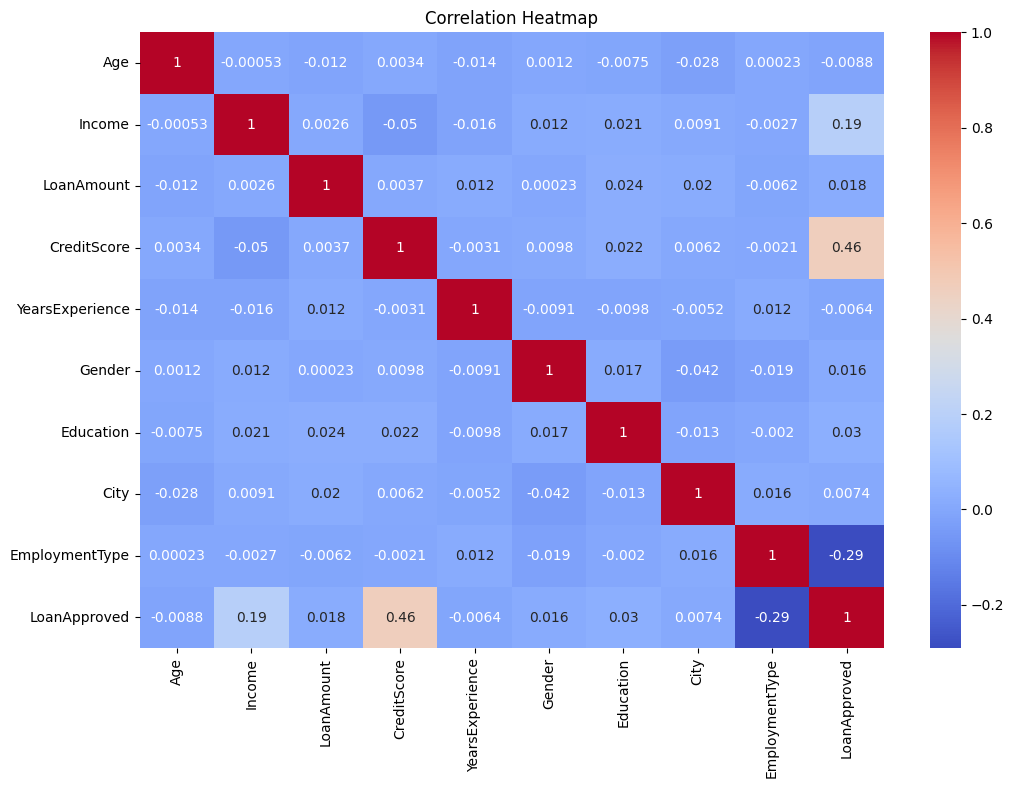

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv('/content/loan_risk_prediction_dataset (1).csv')

# Display Dataset
print(df.head())

# Dataset Info
print(df.info())

# Missing Values
print(df.isnull().sum())

# Encode Categorical Columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Logistic Regression Model
model = LogisticRegression()

# Train Model
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()